# McCabe-Thiele Diagram

The McCabe-Thiele diagram is a classic graphical tool for estimating theoretical stages in binary distillation. The method was introduced as a graphical design procedure for fractionating columns and remains useful for teaching equilibrium balances and operating lines {cite:p}`mccabe1925graphical_design_fractionating_columns`.

This example uses constant relative volatility:

$$
y^*(x)=\frac{\alpha x}{1+(\alpha-1)x}
$$

The rectifying line is:

$$
y=\frac{R}{R+1}x+\frac{x_D}{R+1}
$$

```{admonition} What to modify
:class: dropdown
Change `R`, `alpha`, `xD`, `xF`, or `xB`. A higher reflux ratio moves the rectifying line closer to the diagonal and usually reduces the number of stages, but it increases energy cost.
```


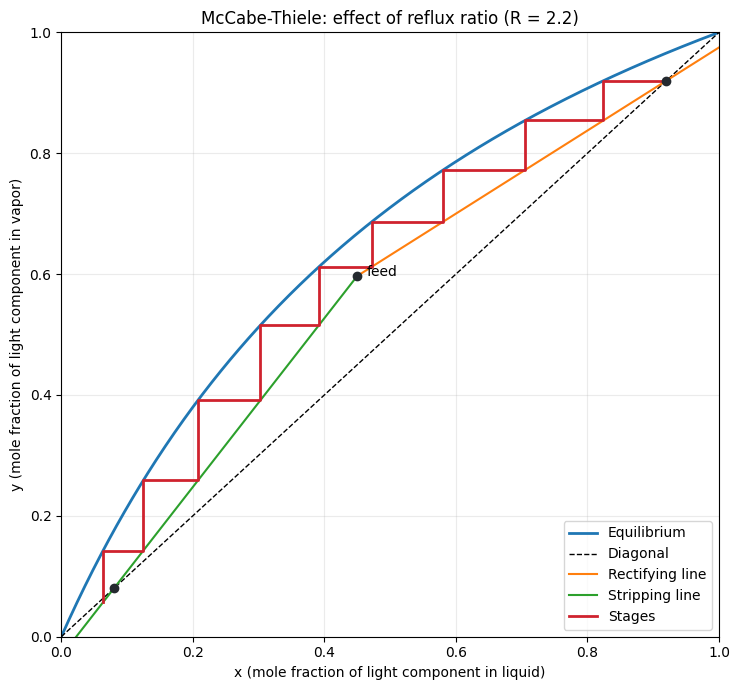

Approximate theoretical stages: 9
xD=0.92, xF=0.45, xB=0.08, alpha=2.45, R=2.20


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
alpha = 2.45   # relative volatility
xF = 0.45      # feed composition
xD = 0.92      # distillate composition
xB = 0.08      # bottoms composition
R = 2.2        # reflux ratio
max_stages = 60


def y_equilibrium(x, alpha):
    return alpha * x / (1 + (alpha - 1) * x)


def x_equilibrium_from_y(y, alpha):
    return y / (alpha - (alpha - 1) * y)


def y_rectifying(x, R, xD):
    return (R / (R + 1)) * x + xD / (R + 1)

# Saturated-liquid feed: q-line is vertical at xF. The stripping line is drawn
# through the feed intersection and the bottoms point on the diagonal.
y_feed = y_rectifying(xF, R, xD)
m_strip = (y_feed - xB) / (xF - xB)
b_strip = xB - m_strip * xB

def y_operating(x):
    return y_rectifying(x, R, xD) if x >= xF else m_strip * x + b_strip

# Staircase construction.
stair_x = [xD]
stair_y = [xD]
stages = 0
x_current = xD
y_current = xD
while x_current > xB and stages < max_stages:
    x_eq = x_equilibrium_from_y(y_current, alpha)
    stair_x.extend([x_eq, x_eq])
    stair_y.extend([y_current, y_operating(x_eq)])
    x_current = x_eq
    y_current = y_operating(x_eq)
    stages += 1

x = np.linspace(0, 1, 500)
plt.figure(figsize=(7.5, 7))
plt.plot(x, y_equilibrium(x, alpha), label="Equilibrium", linewidth=2)
plt.plot(x, x, "k--", label="Diagonal", linewidth=1)
plt.plot(x[x >= xF], y_rectifying(x[x >= xF], R, xD), label="Rectifying line")
plt.plot(x[x <= xF], m_strip * x[x <= xF] + b_strip, label="Stripping line")
plt.plot(stair_x, stair_y, color="#cf222e", linewidth=2, label="Stages")
plt.scatter([xF, xD, xB], [y_feed, xD, xB], color="#24292f", zorder=5)
plt.text(xF + 0.015, y_feed, "feed")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x (mole fraction of light component in liquid)")
plt.ylabel("y (mole fraction of light component in vapor)")
plt.title("McCabe-Thiele: effect of reflux ratio (R = " + str(R) + ")")
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Approximate theoretical stages: {stages}")
print(f"xD={xD:.2f}, xF={xF:.2f}, xB={xB:.2f}, alpha={alpha:.2f}, R={R:.2f}")


## Reading the Result

As the reflux ratio increases, the rectifying line moves closer to the diagonal and fewer stages are required. The energy cost increases because more liquid is recycled inside the column.

```{admonition} Guided reading
:class: dropdown
Count the red staircase steps between $x_D$ and $x_B$. Each step represents one ideal stage: horizontal to equilibrium, then vertical to the operating line.
```
